In [45]:
!pip install torch gymnasium stable-baselines3 pandas numpy matplotlib

In [46]:
import pandas as pd #pd is alias of pandas -> giving other name to pandas which is pd

In [47]:
df = pd.read_csv("/content/thin_film_deposition_rl_dataset.csv")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [48]:
df.head()

,episode,step,temperature_C,pressure_Torr,precursor_flow_sccm,carrier_flow_sccm,rf_power_W,deposition_time_s,current_thickness_nm,film_uniformity_pct,defect_rate_pct,action,reward,next_thickness_nm,done
0,1,0,727.396,1.1511,60.758,121.842,75.651,14.756,6.089,96.402,1.013,observe,3.339,14.295,False
1,1,1,729.154,1.1705,60.824,123.533,76.819,14.498,14.295,95.742,1.169,increase_temperature,1.293,22.348,False
2,1,2,729.055,1.1659,60.143,125.367,76.433,14.370,22.348,96.762,1.123,increase_carrier_flow,4.440,30.046,False
3,1,3,729.880,1.1767,62.285,124.757,75.152,14.126,30.046,97.087,1.132,increase_precursor_flow,6.193,38.006,False
4,1,4,728.200,1.1561,62.935,125.872,76.510,13.926,38.006,96.365,1.131,decrease_temperature,6.594,46.091,False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [49]:
df.shape

(20000, 15)

In [50]:
df.columns

Index(['episode', 'step', 'temperature_C', 'pressure_Torr',
       'precursor_flow_sccm', 'carrier_flow_sccm', 'rf_power_W',
       'deposition_time_s', 'current_thickness_nm', 'film_uniformity_pct',
       'defect_rate_pct', 'action', 'reward', 'next_thickness_nm', 'done'],
      dtype='object')

In [51]:
# Columns we want to use as the RL state
state_columns = [
    "temperature_C",
    "pressure_Torr",
    "precursor_flow_sccm",
    "carrier_flow_sccm",
    "rf_power_W",
    "deposition_time_s",
    "current_thickness_nm",
    "film_uniformity_pct",
    "defect_rate_pct"
]

# Create a clean dataset for our RL project
rl_df = df[state_columns].copy()

# Check the result
print("Original dataset shape:", df.shape)
print("RL dataset shape:", rl_df.shape)

print("\nColumns being used:")
print(rl_df.columns.tolist())

print("\nFirst 5 rows:")
display(rl_df.head())

Original dataset shape: (20000, 15)
RL dataset shape: (20000, 9)

Columns being used:
['temperature_C', 'pressure_Torr', 'precursor_flow_sccm', 'carrier_flow_sccm', 'rf_power_W', 'deposition_time_s', 'current_thickness_nm', 'film_uniformity_pct', 'defect_rate_pct']

First 5 rows:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,temperature_C,pressure_Torr,precursor_flow_sccm,carrier_flow_sccm,rf_power_W,deposition_time_s,current_thickness_nm,film_uniformity_pct,defect_rate_pct
0,727.396,1.1511,60.758,121.842,75.651,14.756,6.089,96.402,1.013
1,729.154,1.1705,60.824,123.533,76.819,14.498,14.295,95.742,1.169
2,729.055,1.1659,60.143,125.367,76.433,14.370,22.348,96.762,1.123
3,729.880,1.1767,62.285,124.757,75.152,14.126,30.046,97.087,1.132
4,728.200,1.1561,62.935,125.872,76.510,13.926,38.006,96.365,1.131


In [52]:
rl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_C         20000 non-null  float64
 1   pressure_Torr         20000 non-null  float64
 2   precursor_flow_sccm   20000 non-null  float64
 3   carrier_flow_sccm     20000 non-null  float64
 4   rf_power_W            20000 non-null  float64
 5   deposition_time_s     20000 non-null  float64
 6   current_thickness_nm  20000 non-null  float64
 7   film_uniformity_pct   20000 non-null  float64
 8   defect_rate_pct       20000 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [53]:
rl_df.isnull().sum()

,0
temperature_C,0
pressure_Torr,0
precursor_flow_sccm,0
carrier_flow_sccm,0
rf_power_W,0
deposition_time_s,0
current_thickness_nm,0
film_uniformity_pct,0
defect_rate_pct,0


In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
rl_df.describe().T

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count,mean,std,min,25%,50%,75%,max
temperature_C,20000.0,701.546138,30.904750,625.573,675.03550,703.1435,727.08675,789.3360
pressure_Torr,20000.0,1.180187,0.251378,0.400,0.97790,1.1818,1.37530,1.8176
precursor_flow_sccm,20000.0,49.905892,9.458291,24.656,42.58400,50.0050,57.16800,79.5640
carrier_flow_sccm,20000.0,109.583180,18.047193,62.074,95.32750,108.8600,123.07325,168.5080
rf_power_W,20000.0,98.076925,20.360286,36.809,81.79875,98.1440,113.61600,168.5730
deposition_time_s,20000.0,9.638350,3.087552,2.000,7.15075,9.5935,12.10125,18.7470
current_thickness_nm,20000.0,70.803123,42.443371,0.002,33.56975,65.7550,114.19975,130.0000
film_uniformity_pct,20000.0,96.462467,0.837743,92.908,95.90775,96.4640,97.03700,99.6660
defect_rate_pct,20000.0,1.022127,0.320412,0.174,0.77775,1.0140,1.25000,2.2390


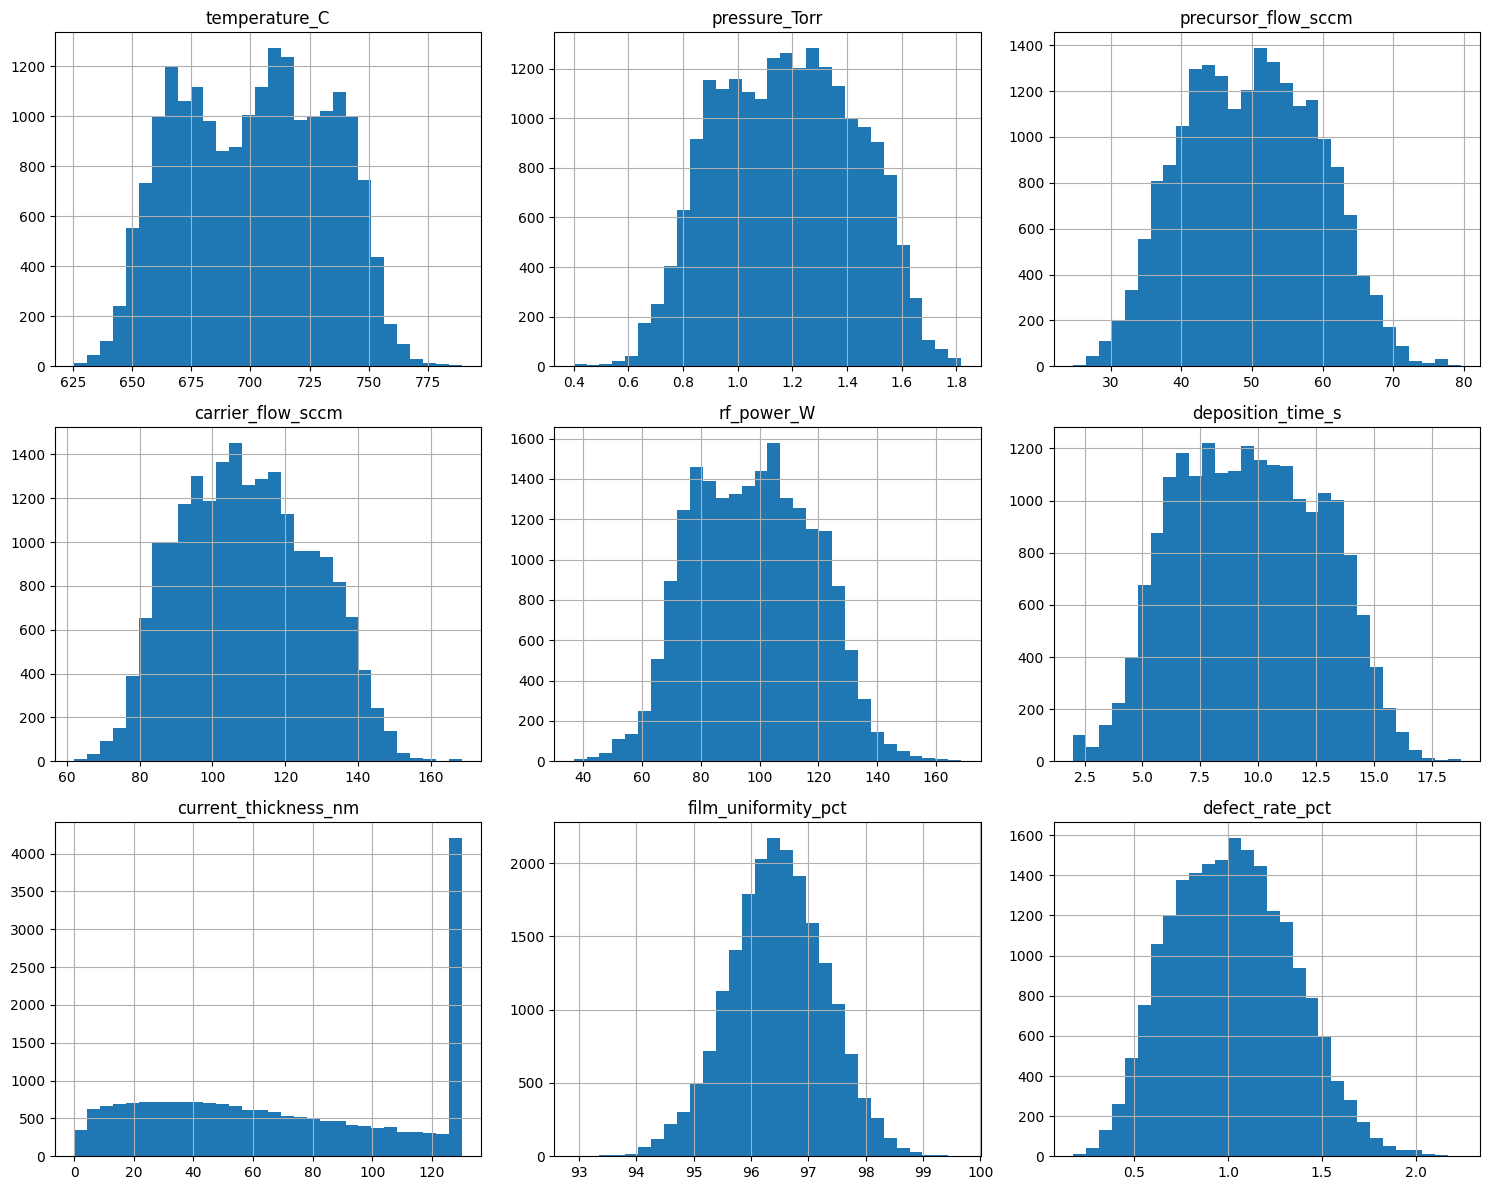

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [56]:
import matplotlib.pyplot as plt

df[state_columns].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [57]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

In [58]:
class ThinFilmDepositionEnv(gym.Env):

    def __init__(self):

        super().__init__()

        # ==========================================
        # ACTION SPACE
        # ==========================================

        # 13 possible actions
        #
        # 0  = Do nothing
        # 1  = Temperature +5°C
        # 2  = Temperature -5°C
        # 3  = Pressure +0.1 Torr
        # 4  = Pressure -0.1 Torr
        # 5  = Precursor flow +5 sccm
        # 6  = Precursor flow -5 sccm
        # 7  = Carrier flow +5 sccm
        # 8  = Carrier flow -5 sccm
        # 9  = RF power +10 W
        # 10 = RF power -10 W
        # 11 = Deposition time +1 s
        # 12 = Deposition time -1 s

        self.action_space = spaces.Discrete(13)


        # ==========================================
        # STATE / OBSERVATION SPACE
        # ==========================================

        # State:
        #
        # [temperature,
        #  pressure,
        #  precursor flow,
        #  carrier flow,
        #  RF power,
        #  deposition time,
        #  current thickness]

        self.observation_space = spaces.Box(
            low=np.array([
                600,    # temperature
                0.4,    # pressure
                20,     # precursor flow
                50,     # carrier flow
                30,     # RF power
                2,      # deposition time
                0       # thickness
            ], dtype=np.float32),

            high=np.array([
                800,    # temperature
                2.5,    # pressure
                90,     # precursor flow
                180,    # carrier flow
                180,    # RF power
                25,     # deposition time
                130     # thickness
            ], dtype=np.float32)
        )


        # Maximum number of actions per episode
        self.max_steps = 50

        self.state = None
        self.steps = 0


    # ==============================================
    # RESET ENVIRONMENT
    # ==============================================

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.steps = 0

        # Random starting conditions
        self.state = np.array([

            self.np_random.uniform(650, 750),   # temperature

            self.np_random.uniform(0.8, 1.6),   # pressure

            self.np_random.uniform(35, 65),     # precursor flow

            self.np_random.uniform(80, 140),    # carrier flow

            self.np_random.uniform(70, 130),    # RF power

            self.np_random.uniform(5, 15),      # deposition time

            self.np_random.uniform(0, 10)       # current thickness

        ], dtype=np.float32)

        return self.state, {}


    # ==============================================
    # STEP
    # ==============================================

    def step(self, action):

        self.steps += 1

        # ------------------------------------------
        # Get current state
        # ------------------------------------------

        (
            temperature,
            pressure,
            precursor,
            carrier,
            rf_power,
            time,
            thickness
        ) = self.state


        # ------------------------------------------
        # APPLY ACTION
        # ------------------------------------------

        if action == 1:

            temperature += 5

        elif action == 2:

            temperature -= 5

        elif action == 3:

            pressure += 0.1

        elif action == 4:

            pressure -= 0.1

        elif action == 5:

            precursor += 5

        elif action == 6:

            precursor -= 5

        elif action == 7:

            carrier += 5

        elif action == 8:

            carrier -= 5

        elif action == 9:

            rf_power += 10

        elif action == 10:

            rf_power -= 10

        elif action == 11:

            time += 1

        elif action == 12:

            time -= 1


        # ------------------------------------------
        # KEEP PARAMETERS WITHIN SAFE LIMITS
        # ------------------------------------------

        temperature = np.clip(
            temperature,
            600,
            800
        )

        pressure = np.clip(
            pressure,
            0.4,
            2.5
        )

        precursor = np.clip(
            precursor,
            20,
            90
        )

        carrier = np.clip(
            carrier,
            50,
            180
        )

        rf_power = np.clip(
            rf_power,
            30,
            180
        )

        time = np.clip(
            time,
            2,
            25
        )


        # ==========================================
        # SIMULATED DEPOSITION PROCESS
        # ==========================================

        # Temperature effect

        temp_factor = np.exp(
            -((temperature - 700) / 55) ** 2
        )


        # Pressure effect

        pressure_factor = np.exp(
            -((pressure - 1.2) / 0.65) ** 2
        )


        # Precursor flow effect

        flow_factor = precursor / 50


        # RF power effect

        power_factor = (
            0.85
            + 0.15 * np.exp(
                -((rf_power - 100) / 45) ** 2
            )
        )


        # Deposition rate

        deposition_rate = (
            0.62
            * temp_factor
            * pressure_factor
            * flow_factor
            * power_factor
        )


        # Thickness increase

        thickness_increase = (
            deposition_rate * time
        )


        # New thickness

        next_thickness = (
            thickness + thickness_increase
        )


        # ==========================================
        # FILM QUALITY
        # ==========================================

        uniformity = (

            98

            - 0.012 * abs(
                temperature - 700
            )

            - 1.2 * abs(
                pressure - 1.2
            )

            - 0.035 * abs(
                precursor - 50
            )

            - 0.018 * abs(
                carrier - 110
            )

            - 0.025 * abs(
                rf_power - 100
            )
        )


        # Defect rate

        defect_rate = (

            0.25

            + 0.018 * abs(
                temperature - 700
            )

            + 0.30 * abs(
                pressure - 1.2
            )

            + 0.012 * abs(
                precursor - 50
            )

            + 0.008 * abs(
                rf_power - 100
            )
        )


        uniformity = np.clip(
            uniformity,
            75,
            99.8
        )

        defect_rate = np.clip(
            defect_rate,
            0.05,
            8
        )


        # ==========================================
        # REWARD
        # ==========================================

        thickness_error = abs(
            100 - next_thickness
        )


        reward = (

            100 * np.exp(
                -thickness_error / 18
            )

            + 2 * (
                uniformity - 90
            )

            - 8 * defect_rate

            - 0.15 * time
        )


        # Bonus for reaching desired condition

        if (

            thickness_error <= 2

            and uniformity >= 95

            and defect_rate <= 1.5

        ):

            reward += 100


        # ==========================================
        # CREATE NEW STATE
        # ==========================================

        self.state = np.array([

            temperature,
            pressure,
            precursor,
            carrier,
            rf_power,
            time,
            next_thickness

        ], dtype=np.float32)


        # ==========================================
        # TERMINATION CONDITIONS
        # ==========================================

        terminated = (

            thickness_error <= 2

            and uniformity >= 95

            and defect_rate <= 1.5
        )


        # Episode ends if maximum steps reached

        truncated = (
            self.steps >= self.max_steps
        )


        # ==========================================
        # ADDITIONAL INFORMATION
        # ==========================================

        info = {

            "thickness": float(
                next_thickness
            ),

            "uniformity": float(
                uniformity
            ),

            "defect_rate": float(
                defect_rate
            )
        }


        # ==========================================
        # RETURN
        # ==========================================

        return (

            self.state.astype(
                np.float32
            ),

            float(reward),

            bool(terminated),

            bool(truncated),

            info
        )

In [59]:
!pip install -q stable-baselines3[extra]

In [60]:
from stable_baselines3 import DQN

In [61]:
env = ThinFilmDepositionEnv()

In [62]:
check_env(env, warn=True)

print("Environment is valid!")

Environment is valid!


In [63]:
state, info = env.reset()

print("Initial state:")
print(state)

print("\nTaking a random action...")

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Action:", action)
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Initial state:
[662.42834     1.3364996  54.415684  116.9231     93.02065    14.972099
   9.808353 ]

Taking a random action...
Action: 11
Next state: [662.42834     1.3364996  54.415684  116.9231     93.02065    15.972099
  16.25211  ]
Reward: 3.812676429748535
Terminated: False
Truncated: False
Info: {'thickness': 16.25210952758789, 'uniformity': 96.93168640136719, 'defect_rate': 1.076062560081482}


In [64]:
model = DQN(
    policy="MlpPolicy",
    env=env,

    learning_rate=1e-3,

    buffer_size=10000,

    learning_starts=1000,

    batch_size=64,

    gamma=0.99,

    train_freq=4,

    target_update_interval=500,

    exploration_fraction=0.3,

    exploration_final_eps=0.05,

    verbose=1,

    seed=42
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
model.learn(
    total_timesteps=50_000,
    progress_bar=True
)

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 33.5     |
|    ep_rew_mean      | 695      |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1155     |
|    time_elapsed     | 0        |
|    total_timesteps  | 134      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38       |
|    ep_rew_mean      | 781      |
|    exploration_rate | 0.981    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1481     |
|    time_elapsed     | 0        |
|    total_timesteps  | 304      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 34.8     |
|    ep_rew_mean      | 773      |
|    exploration_rate | 0.974    |
| time/               |          |
|    episodes       

In [ ]:
model.save("thin_film_dqn")

In [ ]:
obs, info = env.reset()

total_reward = 0

for step in range(50):

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    print(
        f"Step: {step:2d} | "
        f"Action: {action} | "
        f"Thickness: {info['thickness']:.2f} nm | "
        f"Uniformity: {info['uniformity']:.2f}% | "
        f"Defects: {info['defect_rate']:.2f}% | "
        f"Reward: {reward:.2f}"
    )

    if terminated or truncated:
        break

print("\nTotal reward:", total_reward)